In [2]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import torch

torch.set_printoptions(edgeitems=2, linewidth=75)
torch.manual_seed(123)
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)

In [5]:
print(type(cifar10).__mro__) # Print the method resolution order to see the inheritance hierarchy

(<class 'torchvision.datasets.cifar.CIFAR10'>, <class 'torchvision.datasets.vision.VisionDataset'>, <class 'torch.utils.data.dataset.Dataset'>, <class 'typing.Generic'>, <class 'object'>)


In [3]:
print(len(cifar10)) # Print the number of samples in the training set
print(len(cifar10_val)) # Print the number of samples in the validation set

50000
10000


In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print(len(class_names))

10


In [6]:
img, label = cifar10[99]
print(img.size, label, class_names[label])

(32, 32) 1 automobile


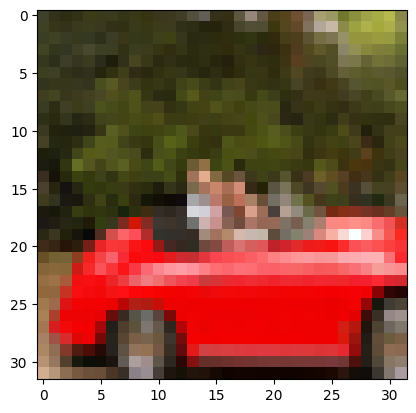

In [7]:
plt.imshow(img) # Display the image

In [8]:
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [9]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [10]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
                          transform=transforms.ToTensor()) # Apply ToTensor transform to dataset

print(tensor_cifar10)

img_t, _ = tensor_cifar10[99]
print(type(img_t))

print(img_t.shape, img_t.dtype)

print(img_t.min(), img_t.max()) # Check the min and max values of the tensor

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../data-unversioned/p1ch7/
    Split: Train
    StandardTransform
Transform: ToTensor()
<class 'torch.Tensor'>
torch.Size([3, 32, 32]) torch.float32
tensor(0.) tensor(1.)


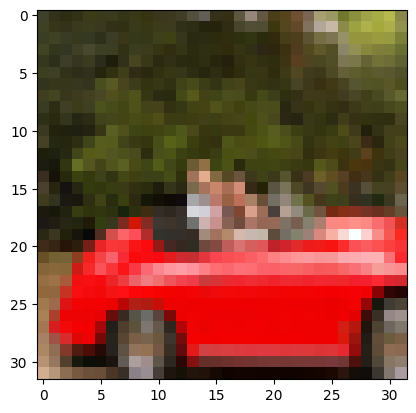

In [29]:
plt.imshow(img_t.permute(1, 2, 0)) # Permute the dimensions to (height, width, channels) from (channels, height, width) for displaying the image
plt.show()

In [30]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3) # Stack all images into a single tensor
print(imgs.shape)

torch.Size([3, 32, 32, 50000])


In [31]:
imgs.view(3, -1).mean(dim=1) # Compute the mean for each channel

tensor([0.4914, 0.4822, 0.4465])

In [32]:
imgs.view(3, -1).std(dim=1) # Compute the standard deviation for each channel

tensor([0.2470, 0.2435, 0.2616])

In [33]:
transforms.Normalize((0.4915, 0.4823, 0.4468), (0.2470, 0.2435, 0.2616)) # Normalize transform with mean and std for each channel

Normalize(mean=(0.4915, 0.4823, 0.4468), std=(0.247, 0.2435, 0.2616))

In [5]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ])) # Apply ToTensor and Normalize transforms to dataset

transformed_cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ])) # Apply ToTensor and Normalize transforms to validation dataset

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9806982..2.126078].


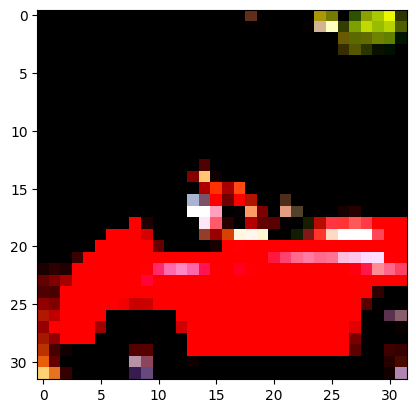

In [35]:
img_t, _ = transformed_cifar10[99] # Get the transformed image

plt.imshow(img_t.permute(1, 2, 0)) # image is transformed from [0, 1] to normalized form, so display will be off
plt.show()

In [15]:
label_map = {0: 0, 2: 1} # Map original labels to new labels
class_names = ['airplane', 'bird'] # New class names
cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10
          if label in [0, 2]] # Filter and relabel the dataset
print(len(cifar2))
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]] # Filter and relabel the validation dataset
print(len(cifar2_val))

10000
2000


In [60]:
n_out = 2

model = nn.Sequential(
    nn.Linear(3*32*32, 512), # Input layer
    nn.Tanh(), # Activation function
    nn.Linear(512, n_out), # Output layer
    nn.LogSoftmax(dim=1) # Softmax activation for output
)
print(model)

Sequential(
  (0): Linear(in_features=3072, out_features=512, bias=True)
  (1): Tanh()
  (2): Linear(in_features=512, out_features=2, bias=True)
  (3): LogSoftmax(dim=1)
)


In [42]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum() # Softmax function implementation

x = torch.tensor([1.0, 2.0, 3.0])
softmax(x)

tensor([0.0900, 0.2447, 0.6652])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8628641..2.029448].


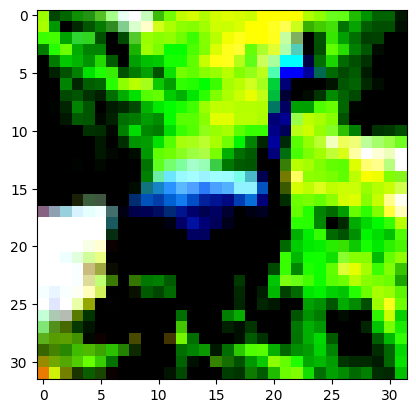

In [54]:
img, _ = cifar2[0]
 
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [55]:
img_batch = img.view(-1).unsqueeze(0) # Flatten the image and add batch dimension
img_batch.shape

torch.Size([1, 3072])

In [61]:
out = model(img_batch)
out

tensor([[-0.6573, -0.7303]], grad_fn=<LogSoftmaxBackward0>)

In [13]:

import numpy as np

# True label: airplane (index 0)
true = np.array([1, 0])  # One-hot encoding for 2 classes

# Predicted probabilities
pred_correct = np.array([0.8, 0.2])  # Correct class has high confidence
pred_wrong = np.array([0.2, 0.8])    # Wrong class has high confidence

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def cross_entropy_loss(y_true, y_pred):
    # Add small epsilon to avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.sum(y_true * np.log(y_pred))

# Compute losses
print("=== Correct Prediction ===")
print("MSE:", mse_loss(true, pred_correct))
print("Cross-Entropy:", cross_entropy_loss(true, pred_correct))

print("\n=== Wrong Prediction ===")
print("MSE:", mse_loss(true, pred_wrong))


=== Correct Prediction ===
MSE: 0.039999999999999994
Cross-Entropy: 0.2231435513142097

=== Wrong Prediction ===
MSE: 0.6400000000000001


In [65]:
img, label = cifar2[0]
 
out = model(img.view(-1).unsqueeze(0)) # Forward pass
loss = nn.NLLLoss() # Define the loss function which is Negative Log Likelihood Loss
loss(out, torch.tensor([label])) # Compute loss


tensor(0.7303, grad_fn=<NllLossBackward0>)

In [8]:
# 1. Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
model = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1)).to(device)
 
learning_rate = 1e-2
 
optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Stochastic Gradient Descent optimizer
 
loss_fn = nn.NLLLoss() # Negative Log Likelihood Loss

n_epochs = 100
 
for epoch in range(n_epochs):
    for img, label in cifar2:
        img = img.to(device)
        label = torch.tensor([label], dtype=torch.long, device=device)
        #out = model(img.view(-1).unsqueeze(0)) # Forward pass
        out = model(img.view(1, -1)) # Forward pass
        loss = loss_fn(out, label) # Compute loss
 
        optimizer.zero_grad() # Zero the gradients
        loss.backward() # Backpropagation
        optimizer.step() # Update weights
 
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\moidhassan\AppData\Local\Temp\ipykernel_52164\946041495.py:27: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 6.094960
Epoch: 1, Loss: 5.599212
Epoch: 2, Loss: 4.253280
Epoch: 3, Loss: 5.899480
Epoch: 4, Loss: 4.385682
Epoch: 5, Loss: 8.690228
Epoch: 6, Loss: 5.723847
Epoch: 7, Loss: 13.022497
Epoch: 8, Loss: 8.816710
Epoch: 9, Loss: 0.988458
Epoch: 10, Loss: 8.887325
Epoch: 11, Loss: 4.164664
Epoch: 12, Loss: 11.210515
Epoch: 13, Loss: 12.743808
Epoch: 14, Loss: 5.078803
Epoch: 15, Loss: 6.543782
Epoch: 16, Loss: 4.085136
Epoch: 17, Loss: 2.865794
Epoch: 18, Loss: 2.129107
Epoch: 19, Loss: 7.774204
Epoch: 20, Loss: 1.219836
Epoch: 21, Loss: 5.378595
Epoch: 22, Loss: 3.667714
Epoch: 23, Loss: 0.092209
Epoch: 24, Loss: 1.047884
Epoch: 25, Loss: 3.392318
Epoch: 26, Loss: 5.325607
Epoch: 27, Loss: 6.536980
Epoch: 28, Loss: 7.008336
Epoch: 29, Loss: 0.899697
Epoch: 30, Loss: 1.586730
Epoch: 31, Loss: 11.845843
Epoch: 32, Loss: 5.998264
Epoch: 33, Loss: 5.475287
Epoch: 34, Loss: 14.328840
Epoch: 35, Loss: 8.742671
Epoch: 36, Loss: 0.296997
Epoch: 37, Loss: 0.722370
Epoch: 38, Loss: 

: 

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1)).to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\moidhassan\AppData\Local\Temp\ipykernel_14292\3298623793.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 0.385184
Epoch: 1, Loss: 0.532509
Epoch: 2, Loss: 0.392664
Epoch: 3, Loss: 0.459422
Epoch: 4, Loss: 0.577409
Epoch: 5, Loss: 0.267795
Epoch: 6, Loss: 0.382747
Epoch: 7, Loss: 0.431259
Epoch: 8, Loss: 0.274276
Epoch: 9, Loss: 0.363709
Epoch: 10, Loss: 0.391776
Epoch: 11, Loss: 0.270728
Epoch: 12, Loss: 0.429431
Epoch: 13, Loss: 0.172186
Epoch: 14, Loss: 0.452300
Epoch: 15, Loss: 0.122251
Epoch: 16, Loss: 0.426224
Epoch: 17, Loss: 0.402878
Epoch: 18, Loss: 0.206674
Epoch: 19, Loss: 0.481379
Epoch: 20, Loss: 0.180869
Epoch: 21, Loss: 0.188839
Epoch: 22, Loss: 0.436197
Epoch: 23, Loss: 0.260408
Epoch: 24, Loss: 0.393310
Epoch: 25, Loss: 0.146592
Epoch: 26, Loss: 0.235262
Epoch: 27, Loss: 0.258482
Epoch: 28, Loss: 0.243859
Epoch: 29, Loss: 0.179859
Epoch: 30, Loss: 0.281512
Epoch: 31, Loss: 0.518087
Epoch: 32, Loss: 0.190882
Epoch: 33, Loss: 0.224980
Epoch: 34, Loss: 0.146574
Epoch: 35, Loss: 0.154428
Epoch: 36, Loss: 0.162443
Epoch: 37, Loss: 0.205707
Epoch: 38, Loss: 0.084

In [11]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.999300


In [16]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.820000


In [17]:
# using CrossEntropyLoss instead of NLLLoss with LogSoftmax

import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2)).to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.430382
Epoch: 1, Loss: 0.481642
Epoch: 2, Loss: 0.515159
Epoch: 3, Loss: 0.452056
Epoch: 4, Loss: 0.674235
Epoch: 5, Loss: 0.423326
Epoch: 6, Loss: 0.340967
Epoch: 7, Loss: 0.560983
Epoch: 8, Loss: 0.458676
Epoch: 9, Loss: 0.286271
Epoch: 10, Loss: 0.204242
Epoch: 11, Loss: 0.276466
Epoch: 12, Loss: 0.355362
Epoch: 13, Loss: 0.586526
Epoch: 14, Loss: 0.570778
Epoch: 15, Loss: 0.506308
Epoch: 16, Loss: 0.509701
Epoch: 17, Loss: 0.284366
Epoch: 18, Loss: 0.281823
Epoch: 19, Loss: 0.139610
Epoch: 20, Loss: 0.322872
Epoch: 21, Loss: 0.422790
Epoch: 22, Loss: 0.131772
Epoch: 23, Loss: 0.567891
Epoch: 24, Loss: 0.266535
Epoch: 25, Loss: 0.115546
Epoch: 26, Loss: 0.217870
Epoch: 27, Loss: 0.252335
Epoch: 28, Loss: 0.156110
Epoch: 29, Loss: 0.471463
Epoch: 30, Loss: 0.177903
Epoch: 31, Loss: 0.063706
Epoch: 32, Loss: 0.195881
Epoch: 33, Loss: 0.275359
Epoch: 34, Loss: 0.306503
Epoch: 35, Loss: 0.126907
Epoch: 36, Loss: 0.229048
Epoch: 37, Loss: 0.101311
Epoch: 38, Loss: 0.225

In [19]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 1.000000


In [20]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.818000


In [21]:
nn.ReLU()

ReLU()

In [22]:
# using CrossEntropyLoss instead of NLLLoss with LogSoftmax, replacing tanh activations with ReLU

import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)).to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.533519
Epoch: 1, Loss: 0.437591
Epoch: 2, Loss: 0.360223
Epoch: 3, Loss: 0.303615
Epoch: 4, Loss: 0.438741
Epoch: 5, Loss: 0.358680
Epoch: 6, Loss: 0.750801
Epoch: 7, Loss: 0.548186
Epoch: 8, Loss: 0.346269
Epoch: 9, Loss: 0.268061
Epoch: 10, Loss: 0.638546
Epoch: 11, Loss: 0.157274
Epoch: 12, Loss: 0.308298
Epoch: 13, Loss: 0.179129
Epoch: 14, Loss: 0.235504
Epoch: 15, Loss: 0.182277
Epoch: 16, Loss: 0.191072
Epoch: 17, Loss: 0.075332
Epoch: 18, Loss: 0.129789
Epoch: 19, Loss: 0.335453
Epoch: 20, Loss: 0.078446
Epoch: 21, Loss: 0.126702
Epoch: 22, Loss: 0.108992
Epoch: 23, Loss: 0.179103
Epoch: 24, Loss: 0.137382
Epoch: 25, Loss: 0.048656
Epoch: 26, Loss: 0.069870
Epoch: 27, Loss: 0.012796
Epoch: 28, Loss: 0.057077
Epoch: 29, Loss: 0.005661
Epoch: 30, Loss: 0.053675
Epoch: 31, Loss: 0.059954
Epoch: 32, Loss: 0.200424
Epoch: 33, Loss: 0.035355
Epoch: 34, Loss: 0.069673
Epoch: 35, Loss: 0.011478
Epoch: 36, Loss: 0.047251
Epoch: 37, Loss: 0.015464
Epoch: 38, Loss: 0.008

Train Accuracy: 1.000000


In [ ]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Train Accuracy: %f" % (correct / total))


val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Validation Accuracy: %f" % (correct / total))

Validation Accuracy: 0.869500


In [27]:
# using CrossEntropyLoss instead of NLLLoss with LogSoftmax, replacing tanh activations with ReLU, with lower learning rate

import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)).to(device)

learning_rate = 1e-3

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 200

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.645627
Epoch: 1, Loss: 0.661739
Epoch: 2, Loss: 0.594128
Epoch: 3, Loss: 0.597951
Epoch: 4, Loss: 0.545695
Epoch: 5, Loss: 0.584208
Epoch: 6, Loss: 0.503231
Epoch: 7, Loss: 0.495205
Epoch: 8, Loss: 0.642920
Epoch: 9, Loss: 0.658803
Epoch: 10, Loss: 0.534228
Epoch: 11, Loss: 0.411457
Epoch: 12, Loss: 0.638702
Epoch: 13, Loss: 0.483624
Epoch: 14, Loss: 0.463320
Epoch: 15, Loss: 0.565870
Epoch: 16, Loss: 0.515343
Epoch: 17, Loss: 0.479050
Epoch: 18, Loss: 0.489212
Epoch: 19, Loss: 0.597037
Epoch: 20, Loss: 0.554314
Epoch: 21, Loss: 0.267886
Epoch: 22, Loss: 0.429034
Epoch: 23, Loss: 0.220044
Epoch: 24, Loss: 0.290605
Epoch: 25, Loss: 0.464778
Epoch: 26, Loss: 0.398656
Epoch: 27, Loss: 0.418675
Epoch: 28, Loss: 0.242022
Epoch: 29, Loss: 0.318262
Epoch: 30, Loss: 0.439477
Epoch: 31, Loss: 0.476850
Epoch: 32, Loss: 0.650030
Epoch: 33, Loss: 0.538340
Epoch: 34, Loss: 0.258069
Epoch: 35, Loss: 0.334705
Epoch: 36, Loss: 0.418507
Epoch: 37, Loss: 0.447691
Epoch: 38, Loss: 0.664

In [28]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Train Accuracy: %f" % (correct / total))


val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Validation Accuracy: %f" % (correct / total))

Train Accuracy: 0.998200
Validation Accuracy: 0.854000


In [32]:
# using CrossEntropyLoss instead of NLLLoss with LogSoftmax, replacing tanh activations with ReLU, with weight decay

import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)).to(device)

learning_rate = 1e-3

optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.675128
Epoch: 1, Loss: 0.639989
Epoch: 2, Loss: 0.647712
Epoch: 3, Loss: 0.630876
Epoch: 4, Loss: 0.616104
Epoch: 5, Loss: 0.615815
Epoch: 6, Loss: 0.513204
Epoch: 7, Loss: 0.493037
Epoch: 8, Loss: 0.676390
Epoch: 9, Loss: 0.401900
Epoch: 10, Loss: 0.452463
Epoch: 11, Loss: 0.515093
Epoch: 12, Loss: 0.599138
Epoch: 13, Loss: 0.530324
Epoch: 14, Loss: 0.588625
Epoch: 15, Loss: 0.421559
Epoch: 16, Loss: 0.471384
Epoch: 17, Loss: 0.535648
Epoch: 18, Loss: 0.545311
Epoch: 19, Loss: 0.449531
Epoch: 20, Loss: 0.371855
Epoch: 21, Loss: 0.456756
Epoch: 22, Loss: 0.371591
Epoch: 23, Loss: 0.780713
Epoch: 24, Loss: 0.278837
Epoch: 25, Loss: 0.556979
Epoch: 26, Loss: 0.296687
Epoch: 27, Loss: 0.372625
Epoch: 28, Loss: 0.352113
Epoch: 29, Loss: 0.626136
Epoch: 30, Loss: 0.300115
Epoch: 31, Loss: 0.372085
Epoch: 32, Loss: 0.618221
Epoch: 33, Loss: 0.479708
Epoch: 34, Loss: 0.424251
Epoch: 35, Loss: 0.521009
Epoch: 36, Loss: 0.244583
Epoch: 37, Loss: 0.397462
Epoch: 38, Loss: 0.492

In [33]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Train Accuracy: %f" % (correct / total))


val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Validation Accuracy: %f" % (correct / total))

Train Accuracy: 0.925500
Validation Accuracy: 0.859000


In [30]:
# using CrossEntropyLoss instead of NLLLoss with LogSoftmax, replacing tanh activations with ReLU, adding dropout

import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 2)).to(device)

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.512714
Epoch: 1, Loss: 0.611845
Epoch: 2, Loss: 0.367375
Epoch: 3, Loss: 0.581103
Epoch: 4, Loss: 0.560598
Epoch: 5, Loss: 0.286215
Epoch: 6, Loss: 0.587817
Epoch: 7, Loss: 0.504539
Epoch: 8, Loss: 0.216620
Epoch: 9, Loss: 0.167335
Epoch: 10, Loss: 0.523365
Epoch: 11, Loss: 0.355902
Epoch: 12, Loss: 0.522957
Epoch: 13, Loss: 0.673985
Epoch: 14, Loss: 0.257858
Epoch: 15, Loss: 0.290048
Epoch: 16, Loss: 0.561109
Epoch: 17, Loss: 0.152002
Epoch: 18, Loss: 0.145078
Epoch: 19, Loss: 0.177528
Epoch: 20, Loss: 0.329689
Epoch: 21, Loss: 0.278888
Epoch: 22, Loss: 0.332673
Epoch: 23, Loss: 0.263099
Epoch: 24, Loss: 0.372428
Epoch: 25, Loss: 0.424519
Epoch: 26, Loss: 0.270779
Epoch: 27, Loss: 0.173036
Epoch: 28, Loss: 0.626171
Epoch: 29, Loss: 0.190885
Epoch: 30, Loss: 0.090486
Epoch: 31, Loss: 0.583446
Epoch: 32, Loss: 0.192659
Epoch: 33, Loss: 0.301144
Epoch: 34, Loss: 0.337485
Epoch: 35, Loss: 0.430668
Epoch: 36, Loss: 0.283908
Epoch: 37, Loss: 0.127270
Epoch: 38, Loss: 0.201

In [31]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Train Accuracy: %f" % (correct / total))


val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Validation Accuracy: %f" % (correct / total))

Train Accuracy: 0.978000
Validation Accuracy: 0.857000
